<a href="https://www.kaggle.com/code/adastroabyssosque/track-2-eda-xgboost-lstm?scriptVersionId=313557701" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# import libraries and data

In [1]:
!pip install scikeras

In [2]:
import numpy as np 
import pandas as pd 
import orjson
from matplotlib import pyplot as plt
from pathlib import Path
from concurrent.futures import ProcessPoolExecutor
import os
import seaborn as sns
import missingno as msno
import math
from scipy.signal import find_peaks
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline, make_pipeline
from mlxtend.evaluate.time_series import GroupTimeSeriesSplit, print_split_info
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import make_scorer, f1_score
from sklearn.model_selection import cross_val_score
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Bidirectional, LSTM, Dense
from scikeras.wrappers import KerasClassifier
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

2026-04-22 09:10:29.693909: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776849029.928900      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776849030.005396      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776849030.611078      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776849030.611121      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776849030.611135      55 computation_placer.cc:177] computation placer alr

In [3]:
track1 = pd.read_json('/kaggle/input/competitions/cvpr-2026-the-first-ai-children-challenge/track1_train.json')
track2 = pd.read_json('/kaggle/input/competitions/cvpr-2026-the-first-ai-children-challenge/track2_train.json')
global track1 
global track2

In [4]:
track1.head()

,patient_id,left,right
0,1,"{'1': 0, '2': 1, '3': 0, '4': 1, '5': 1, '6': ...","{'1': 0, '2': 1, '3': 0, '4': 1, '5': 1, '6': ..."
1,2,"{'1': 0, '2': 0, '3': 0, '4': 0, '5': 0, '6': ...","{'1': 1, '2': 1, '3': 0, '4': 0, '5': 1, '6': ..."
2,3,"{'1': 0, '2': 1, '3': 0, '4': 0, '5': 0, '6': ...","{'1': 1, '2': 1, '3': 0, '4': 0, '5': 1, '6': ..."
3,6,"{'1': 1, '2': 1, '3': 0, '4': 1, '5': 0, '6': ...","{'1': 0, '2': 0, '3': 0, '4': 1, '5': 0, '6': ..."
4,7,"{'1': 1, '2': 1, '3': 0, '4': 0, '5': 1, '6': ...","{'1': 1, '2': 1, '3': 0, '4': 0, '5': 1, '6': ..."


In [5]:
track2.head()

,patient_id,left,right
0,1,{'gait_subtype': 'type3'},{'gait_subtype': 'type3'}
1,5,{'gait_subtype': 'type3'},{'gait_subtype': 'type3'}
2,12,{'gait_subtype': 'type3'},{'gait_subtype': 'type3'}
3,18,{'gait_subtype': 'type2'},{'gait_subtype': 'type2'}
4,21,{'gait_subtype': 'type2'},{'gait_subtype': 'type2'}


# Metadata Preprocessing & EDA

In [6]:
def processing_metadata(track1 = track1, track2 = track2):
    for i in range(1, 18):
        track1['L'+str(i)] = track1['left'].apply(lambda x: x[str(i)])
        track1['R'+str(i)] = track1['right'].apply(lambda x: x[str(i)])
    track1_scored_item = ['L']
    track1 = track1.drop(['left', 'right'], axis=1)
    track2['Left_gait_subtype'] = track2['left'].map(lambda x: x['gait_subtype'])
    track2['Right_gait_subtype'] = track2['right'].map(lambda x: x['gait_subtype'])
    track2 = track2.drop(['left', 'right'], axis = 1)
    return track1, track2

In [7]:
track1, track2 = processing_metadata()
track1.head()

,patient_id,L1,R1,L2,R2,L3,R3,L4,R4,L5,...,L13,R13,L14,R14,L15,R15,L16,R16,L17,R17
0,1,0,0,1,1,0,0,1,1,1,...,0,0,1,0,1,1,1,1,0,0
1,2,0,1,0,1,0,0,0,0,0,...,0,0,1,1,0,0,0,0,0,0
2,3,0,1,1,1,0,0,0,0,0,...,0,0,0,1,1,0,1,1,0,1
3,6,1,0,1,0,0,0,1,1,0,...,0,0,0,0,1,1,0,1,0,0
4,7,1,1,1,1,0,0,0,0,1,...,0,0,1,0,1,1,1,1,1,1


In [8]:
track2.head()

,patient_id,Left_gait_subtype,Right_gait_subtype
0,1,type3,type3
1,5,type3,type3
2,12,type3,type3
3,18,type2,type2
4,21,type2,type2


# Q1: how many patients do we have

In [9]:
print(track1.shape[0])
print(track2.shape[0])

94
22


## Q2: do patients have the same gait type at left and right?

In [10]:
track2.loc[track2['Left_gait_subtype']!=track2['Right_gait_subtype']]

,patient_id,Left_gait_subtype,Right_gait_subtype
11,32,type2,type3
15,48,type1,type3


## Q3: how many patients have left EVGS scoring different from their right?

In [11]:
def sum_svgs_per_leg(track1 = track1):
    left = ['L'+str(i) for i in range(1, 18)]
    right = ['R'+str(i) for i in range(1, 18)]
    track1['Left_SVGS_Score'] = track1.loc[:,left].sum(axis = 1)
    track1['Right_SVGS_Score'] = track1.loc[:,right].sum(axis = 1)
    return track1

In [12]:
track1 = sum_svgs_per_leg()

In [13]:
track1[['Left_SVGS_Score', 'Right_SVGS_Score']].describe()

,Left_SVGS_Score,Right_SVGS_Score
count,94.000000,94.000000
mean,5.840426,5.989362
std,3.312742,3.227885
min,1.000000,0.000000
25%,3.000000,3.000000
50%,5.000000,6.000000
75%,8.000000,8.000000
max,13.000000,14.000000


In [14]:
track2.Left_gait_subtype.value_counts()

Left_gait_subtype
type2    8
type3    6
type1    6
WNL      1
type4    1
Name: count, dtype: int64

In [15]:
def get_id(s):
    num = 0
    for i in range(-1, -len(s)-1, -1):
        num+=10**(-i-1)*int(s[i])
    return(num)

In [16]:
# Define points2keep and cols outside so they are accessible
POINTS2KEEP = [1, 2, 3, 6, 7, 12, 13, 14, 15, 16, 17, 18, 21, 19, 22, 20, 23]
COLS = ['patient_id','frame', 'nose', 'eye_l', 'eye_r', 'shoulder_l', 'shoulder_r', 'hip_l', 'hip_r', 'knee_l', 'knee_r', 'ankle_l', 
        'ankle_r', 'toe1_l', 'toe1_r', 'toe5_l', 'toe5_r', 'heel_l', 'heel_r', 'nose_CI', 'eye_l_CI', 'eye_r_CI', 'shoulder_l_CI', 
        'shoulder_r_CI', 'hip_l_CI', 'hip_r_CI', 'knee_l_CI', 'knee_r_CI','ankle_l_CI', 'ankle_r_CI',
        'toe1_l_CI', 'toe1_r_CI', 'toe5_l_CI','toe5_r_CI', 'heel_l_CI', 'heel_r_CI', 'bbox']

def process_file(frame_path):
    try:
        # Extract patient_id from the path (e.g., .../dataset/001/front/...)
        patient_id = frame_path.parts[-3] 
        frame = frame_path.parts[-1].split('.')[0].split('_')[1]
        
        with open(frame_path, 'r') as f:
            data = orjson.loads(f.read())
            inst = data['instance_info'][0]
            
            kp = inst['keypoints']
            ks = inst['keypoint_scores']
            bbox = inst.get('gt_bbox_xywh_px')
            
            record = [get_id(patient_id), get_id(frame)+1]
            kp_row = []
            ks_row = []
            for idx in POINTS2KEEP: 
                if ks[idx-1]>0.3: 
                    kp_row.append(kp[idx-1])
                    ks_row.append(ks[idx-1])
                else: 
                     kp_row.append(None)
                     ks_row.append(None)
            record.extend(kp_row)
            record.extend(ks_row)
            record.append(bbox)
            return record
    except Exception as e:
        pass
        
def organize_df_parallel(side_filter):
    base_path = Path(r'/kaggle/input/datasets/adastroabyssosque/first-ai-for-children-competition-data/dataset/')
    
    print("Scanning for files...")
    # Get only the files that match your side filter
    all_frames = [f for f in base_path.rglob("*.json") if side_filter in f.parent.name.lower()]
    
    #print(f"Starting parallel processing of {len(all_frames)} files...")
    
    # ProcessPoolExecutor automatically uses all available CPU cores
    with ProcessPoolExecutor() as executor:
        results = list(executor.map(process_file, all_frames))
    
    # Filter out None results from errors and create DataFrame
    clean_results = [r for r in results if r is not None]
    return pd.DataFrame(clean_results, columns=COLS).sort_values(by = ['patient_id', 'frame'])

# Run it!
print('Gathering points from front view...')
front_df = organize_df_parallel('forward')
print('Gathering points from back veiw...')
back_df = organize_df_parallel('backward')
print('Gathering points from left view...')
left_df = organize_df_parallel('left')
print('Gathering points from right view...')
right_df = organize_df_parallel('right')

print(front_df.shape)
print(back_df.shape)
print(left_df.shape)
print(right_df.shape)

Gathering points from front view...
Scanning for files...
Gathering points from back veiw...
Scanning for files...
Gathering points from left view...
Scanning for files...
Gathering points from right view...
Scanning for files...
(90107, 37)
(83560, 37)
(88235, 37)
(77240, 37)


In [17]:
front_df.head()

,patient_id,frame,nose,eye_l,eye_r,shoulder_l,shoulder_r,hip_l,hip_r,knee_l,...,knee_r_CI,ankle_l_CI,ankle_r_CI,toe1_l_CI,toe1_r_CI,toe5_l_CI,toe5_r_CI,heel_l_CI,heel_r_CI,bbox
81342,1,1,"[924.1079859408351, 407.402328024874]","[936.6422530128646, 399.23822595932904]","[912.7967875733343, 400.99091414078407]","[961.8707720591487, 453.06823533527995]","[888.2738041606981, 454.60429773676196]","[951.6175264599392, 564.4828935707171]","[902.7504813746496, 563.3792428833889]","[944.0239652608745, 648.8910972430133]",...,0.992568,0.914305,0.936415,0.961659,0.973558,0.914794,1.039369,0.935840,0.889952,"[863, 352, 131, 413]"
81343,1,2,"[923.8622677015965, 405.65517202679473]","[938.9937641132276, 397.28344035127077]","[912.465325526859, 399.1986004712352]","[962.4319873113034, 452.5797659672139]","[888.924877981548, 454.01982127490146]","[950.9392930254978, 565.9845889170819]","[900.2066143525092, 563.1217746723735]","[943.0548519108088, 649.4576217057074]",...,0.988193,0.912326,0.935299,0.971474,0.960123,0.914115,1.033210,0.919249,0.889955,"[864, 351, 131, 414]"
81335,1,3,"[926.2101347830064, 403.9169256920434]","[938.4691812727692, 395.64561532033497]","[914.3094212165204, 397.5920057044967]","[962.3491882372414, 451.95710148844205]","[889.0404666410418, 453.4735076094521]","[951.5807503946173, 564.881647380792]","[900.2073609135505, 562.4148943230218]","[943.2920415864, 649.8762830470998]",...,0.986799,0.935134,0.957220,0.968027,0.973709,0.919493,1.044257,0.944103,0.913161,"[863, 350, 132, 415]"
81250,1,4,"[927.567073959116, 403.37285391894693]","[938.1941409829069, 395.5737559403275]","[915.8929795243957, 397.7851176875406]","[963.2001854427822, 451.3227859807512]","[889.4257236100655, 452.0592777145771]","[953.612496484973, 563.3754276229032]","[900.0546936416238, 561.5904094906414]","[943.9733890035623, 650.0832705848795]",...,0.979630,0.910594,0.935143,0.958100,0.984666,0.895671,1.039855,0.920499,0.884664,"[864, 348, 131, 418]"
81336,1,5,"[927.9519815138342, 399.4823789003798]","[940.621819441292, 391.3825721513233]","[914.8303548678443, 393.3295731272905]","[963.6148777789954, 449.9104543303906]","[889.6786962876447, 450.13663714239374]","[953.2115551127554, 562.4669147663037]","[899.7826381777363, 560.696081173935]","[944.7597737923747, 650.5011438809554]",...,0.964629,0.824175,0.959844,0.951411,0.984490,0.892176,1.047742,0.921520,0.914944,"[864, 345, 131, 421]"


# Q4. Finally finished loading data, how does it look like?

In [18]:
CI = [ 'nose_CI', 'shoulder_l_CI', 
        'shoulder_r_CI', 'hip_l_CI', 'hip_r_CI', 'knee_l_CI', 'knee_r_CI','ankle_l_CI', 'ankle_r_CI',
        'toe1_l_CI', 'toe1_r_CI', 'toe5_l_CI','toe5_r_CI', 'heel_l_CI', 'heel_r_CI']

In [19]:
corrupted = front_df.loc[(front_df['patient_id']==53) & (front_df['frame']>1297)]
front_df.drop(corrupted.index, inplace=True)

In [20]:
def get_angle(u, v, o):
    if u is None or v is None or o is None: 
        return None
    o_x, o_y = o[0], o[1]
    u_x, u_y = u[0], u[1]
    v_x, v_y = v[0], v[1]
    u_x = u_x-o_x
    v_x = v_x-o_x
    u_y = u_y-o_y
    v_y = v_y-o_y

    u_dot_v = u_x*v_x+u_y*v_y
    mag_u = math.sqrt(u_x**2+u_y**2)
    mag_v = math.sqrt(v_x**2+v_y**2)
    if mag_u == 0 or mag_v == 0:
        return 0.0

    cos_theta = u_dot_v/(mag_u*mag_v)

    return math.degrees(math.acos(min(max(cos_theta, -1.0), 1.0) ))

In [21]:
def get_angles_df(df): 
    df['eye-hip-angle_l'] = df.apply(lambda x: get_angle(x['eye_l'], x['hip_l'], x['shoulder_l']), axis = 1)
    df['hip-ankle-angle_l'] = df.apply(lambda x: get_angle(x['hip_l'], x['ankle_l'], x['knee_l']), axis = 1)
    df['knee-toe1-angle_l'] = df.apply(lambda x: get_angle(x['knee_l'], x['toe1_l'], x['ankle_l']), axis = 1)
    df['knee-toe5-angle_l'] = df.apply(lambda x:  get_angle(x['knee_l'], x['toe5_l'], x['ankle_l']), axis = 1)
    df['knee-toe1-angle-heel_l'] = df.apply(lambda x: get_angle(x['knee_l'], x['toe1_l'], x['heel_l']), axis = 1)
    df['knee-toe5-angle-heel_l'] = df.apply(lambda x: get_angle(x['knee_l'], x['toe5_l'], x['heel_l']), axis = 1)
    df['eye-hip-angle_r'] = df.apply(lambda x: get_angle(x['eye_r'], x['hip_r'], x['shoulder_r']), axis = 1)
    df['hip-ankle-angle_r'] = df.apply(lambda x: get_angle(x['hip_r'], x['ankle_r'], x['knee_r']), axis = 1)
    df['knee-toe1-angle_r'] = df.apply(lambda x: get_angle(x['knee_r'], x['toe1_r'], x['ankle_r']), axis = 1)
    df['knee-toe5-angle_r'] = df.apply(lambda x:  get_angle(x['knee_r'], x['toe5_r'], x['ankle_r']), axis = 1)
    df['knee-toe1-angle-heel_r'] = df.apply(lambda x: get_angle(x['knee_r'], x['toe1_r'], x['heel_r']), axis = 1)
    df['knee-toe5-angle-heel_r'] = df.apply(lambda x: get_angle(x['knee_r'], x['toe5_r'], x['heel_r']), axis = 1)

    return df

In [22]:
front_df = get_angles_df(front_df)
back_df = get_angles_df(back_df)
left_df = get_angles_df(left_df)
right_df = get_angles_df(right_df)

In [23]:
def kpt_explode(df):
    kpt = ['nose', 'eye_l', 'eye_r', 'shoulder_l', 'shoulder_r', 'hip_l', 'hip_r', 'knee_l', 'knee_r', 'ankle_l', 
        'ankle_r', 'toe1_l', 'toe1_r', 'toe5_l', 'toe5_r', 'heel_l', 'heel_r']
    for pt in kpt: 
        df[pt+'_x'] = df.apply(lambda x: (x[pt][0]-x['bbox'][0]) if x[pt] != None and x['bbox']!= None  else -1, axis = 1)
        df[pt+'_y'] = df.apply(lambda x: (x[pt][1]-x['bbox'][1]) if x[pt] != None and x['bbox']!= None else -1, axis = 1)

        df[pt+'_x'] = df.apply(lambda x: x[pt+'_x']/x['bbox'][0] if x['bbox']!=None and x['bbox'][0]!=0 else x[pt+'_x'], axis = 1)
        df[pt+'_y'] = df.apply(lambda x: x[pt+'_y']/x['bbox'][1] if x['bbox']!=None and x['bbox'][1]!=0 else x[pt+'_y'], axis = 1)
    df.drop(columns= kpt, axis = 1, inplace = True)
    return df

In [24]:
left_df_test = kpt_explode(left_df.copy())

In [25]:
patient1 = left_df_test.loc[left_df_test['patient_id']==1]

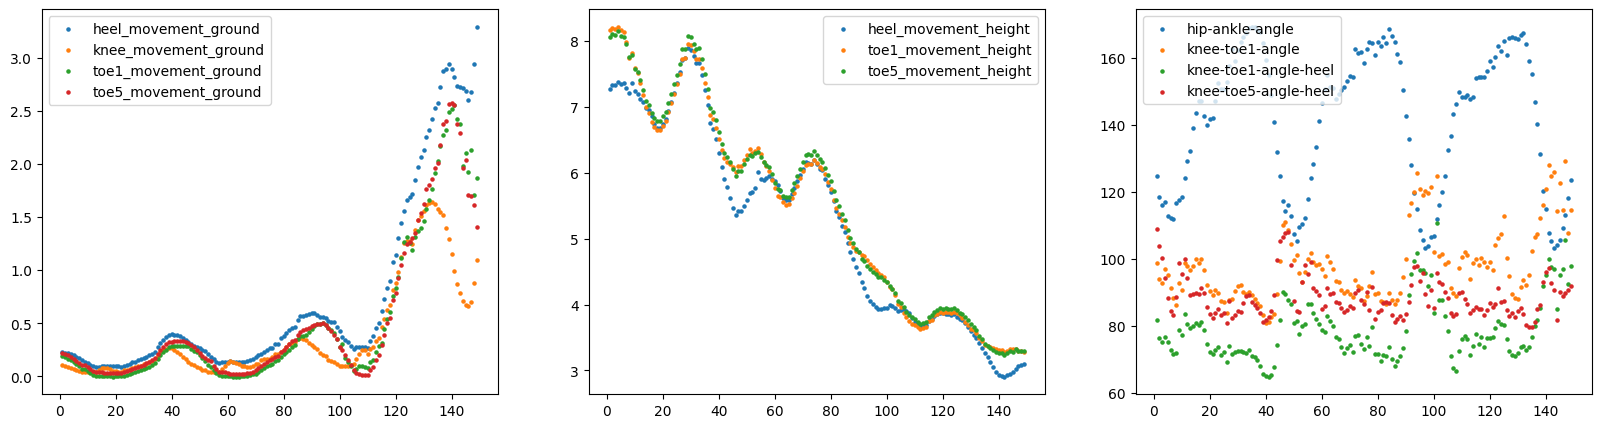

In [26]:
fig, ax = plt.subplots(1,3, figsize = (20, 5))
ax[0].scatter(x = patient1['frame'], y = patient1['heel_l_x'], label = 'heel_movement_ground', s = 5)
ax[0].scatter(x = patient1['frame'], y = patient1['knee_l_x'], label = 'knee_movement_ground', s = 5)
ax[0].scatter(x = patient1['frame'], y = patient1['toe1_l_x'], label = 'toe1_movement_ground', s = 5)
ax[0].scatter(x = patient1['frame'], y = patient1['toe5_l_x'], label = 'toe5_movement_ground', s = 5)
#ax[0].scatter(x = patient1['frame'], y = patient1['shoulder_l_x'], label = 'shoulder_movement_ground', s = 5)
ax[0].legend()

ax[1].scatter(x = patient1['frame'], y = patient1['heel_l_y'], label = 'heel_movement_height', s = 5)
#ax[1].scatter(x = patient1['frame'], y = patient1['knee_l_y'], label = 'knee_movement_height', s = 5)
ax[1].scatter(x = patient1['frame'], y = patient1['toe1_l_y'], label = 'toe1_movement_height', s = 5)
ax[1].scatter(x = patient1['frame'], y = patient1['toe5_l_y'], label = 'toe5_movement_height', s = 5)
ax[1].legend()

#ax[2].scatter(x = patient1['frame'], y = patient1['eye-hip-angle'], label = 'eye-hip-angle', s = 5)
ax[2].scatter(x = patient1['frame'], y = patient1['hip-ankle-angle_l'], label = 'hip-ankle-angle', s = 5)
ax[2].scatter(x = patient1['frame'], y = patient1['knee-toe1-angle_l'], label = 'knee-toe1-angle', s = 5)
#ax[2].scatter(x = patient1['frame'], y = patient1['knee-toe5-angle'], label = 'knee-toe5-angle', s = 5)
ax[2].scatter(x = patient1['frame'], y = patient1['knee-toe1-angle-heel_l'], label = 'knee-toe1-angle-heel', s = 5)
ax[2].scatter(x = patient1['frame'], y = patient1['knee-toe5-angle-heel_l'], label = 'knee-toe5-angle-heel', s = 5)
ax[2].legend()

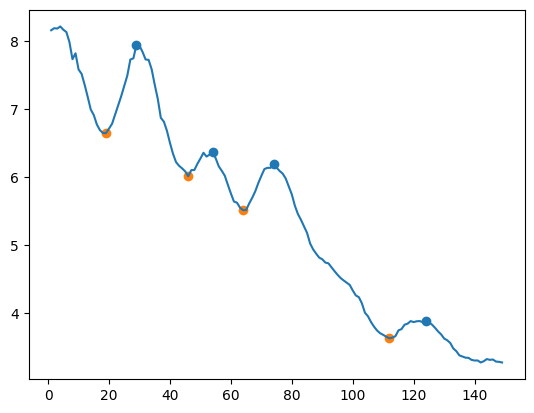

In [27]:
peaks, _ = find_peaks(patient1['toe1_l_y'], width = 5)
low, _ = find_peaks(-patient1['toe1_l_y'], width = 5)
fig, ax = plt.subplots()
ax.scatter(patient1['frame'].values[peaks], patient1['toe1_l_y'].values[peaks], label = 'touching found')
ax.scatter(patient1['frame'].values[low], patient1['toe1_l_y'].values[low], label = 'midstep')
ax.plot(patient1['frame'], patient1['toe1_l_y'], label = 'heel_movement_height',)

In [28]:
def get_peak_vectorized(group):
    # Get peak indices for this patient's signal
    peaks, _ = find_peaks(group['toe1_l_y'], width=1)
    lows, _ = find_peaks(-group['toe1_l_y'], width=1)
    # Create a boolean mask initialized to False
    group['midstep'] = False
    group['touch_ground'] = False
    # Efficiently update peak positions using iloc
    if len(peaks) > 0:
        group.iloc[peaks, group.columns.get_loc('midstep')] = True
    if len(lows)>0: 
        group.iloc[lows, group.columns.get_loc('touch_ground')] = True
    return group

In [29]:
front_df = kpt_explode(front_df)
back_df = kpt_explode(back_df)
left_df = kpt_explode(left_df)
right_df =kpt_explode(right_df)

front_df = front_df.groupby('patient_id', group_keys=False).apply(get_peak_vectorized)
back_df = back_df.groupby('patient_id', group_keys=False).apply(get_peak_vectorized)
left_df = left_df.groupby('patient_id', group_keys=False).apply(get_peak_vectorized)
right_df = right_df.groupby('patient_id', group_keys=False).apply(get_peak_vectorized)

/tmp/ipykernel_55/44329767.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  front_df = front_df.groupby('patient_id', group_keys=False).apply(get_peak_vectorized)
/tmp/ipykernel_55/44329767.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  back_df = back_df.groupby('patient_id', group_keys=False).apply(get_peak_vectorized)
/tmp/ipykernel_55/44329767.py:8: FutureWarning: DataFrameGroupBy.apply operated on the gro

In [120]:
T1 = [4, 5, 18, 26, 28, 40, 42, 43, 47, 48, 53, 54, 72, 78, 83, 85]
T2 = [4, 6, 7, 13, 26, 35, 39, 42, 50]

test_t1_front = front_df.loc[front_df['patient_id'].isin(T1)]
test_t1_back = back_df.loc[back_df['patient_id'].isin(T1)]
test_t1_left = left_df.loc[left_df['patient_id'].isin(T1)]
test_t1_right = right_df.loc[left_df['patient_id'].isin(T1)]
test_t2_front = front_df.loc[front_df['patient_id'].isin(T2)]
test_t2_back = back_df.loc[back_df['patient_id'].isin(T2)]
test_t2_left = left_df.loc[left_df['patient_id'].isin(T2)]
test_t2_right = right_df.loc[left_df['patient_id'].isin(T2)]

print('T1 data shape in test T1: ')
print(f'Front: {test_t1_front.shape}')
print(f'Back: {test_t1_back.shape}')
print(f'Left: {test_t1_left.shape}')
print(f'Right: {test_t1_right.shape}')
print('T2 data shape in test T1: ')
print(f'Front: {test_t2_front.shape}')
print(f'Back: {test_t2_back.shape}')
print(f'Left: {test_t2_left.shape}')
print(f'Right: {test_t2_right.shape}')

train_t1_front = front_df.merge(track1, on = 'patient_id', how = 'inner')
train_t1_back = back_df.merge(track1, on = 'patient_id', how = 'inner')
train_t1_left = left_df.merge(track1, on = 'patient_id', how = 'inner')
train_t1_right = right_df.merge(track1, on = 'patient_id', how = 'inner')
train_t2_front = front_df.merge(track2, on = 'patient_id', how = 'inner')
train_t2_back = back_df.merge(track2, on = 'patient_id', how = 'inner')
train_t2_left = left_df.merge(track2, on = 'patient_id', how = 'inner')
train_t2_right = right_df.merge(track2, on = 'patient_id', how = 'inner')

print('T1 data shape in train T1: ')
print(f'Front: {train_t1_front.shape}')
print(f'Back: {train_t1_back.shape}')
print(f'Left: {train_t1_left.shape}')
print(f'Right: {train_t1_right.shape}')
print('T2 data shape in train T1: ')
print(f'Front: {train_t2_front.shape}')
print(f'Back: {train_t2_back.shape}')
print(f'Left: {train_t2_left.shape}')
print(f'Right: {train_t2_right.shape}')

T1 data shape in test T1: 
Front: (16371, 68)
Back: (12520, 68)
Left: (14485, 68)
Right: (14485, 68)
T2 data shape in test T1: 
Front: (8756, 68)
Back: (7321, 68)
Left: (8495, 68)
Right: (8495, 68)
T1 data shape in train T1: 
Front: (73643, 104)
Back: (71040, 104)
Left: (73750, 104)
Right: (64022, 104)
T2 data shape in train T1: 
Front: (18817, 70)
Back: (17440, 70)
Left: (15082, 70)
Right: (12017, 70)


In [121]:
train_t2_left = train_t2_left.fillna(-1)
train_t2_right = train_t2_right.fillna(-1)

In [122]:
def acc2(y_true, y_pred):
    return sum(y_true == y_pred) / y_true.shape[0]

#acc2 = make_scorer(acc2)

In [123]:
train_t2_left.drop('Right_gait_subtype', axis = 1, inplace = True)
train_t2_left['Left_gait_subtype'] = train_t2_left['Left_gait_subtype'].map({'WNL': 0, 'type1': 1,'type2': 2,'type3': 3, 'type4':4})
y_left = train_t2_left.pop('Left_gait_subtype')
train_t2_left.drop('bbox', axis = 1, inplace = True)
smote_pipeline = make_pipeline(SMOTE(sampling_strategy = 'not majority', k_neighbors = 5, random_state=42), 
                               XGBClassifier(objective = 'multi:softprob', num_class = 5))
cv_params = {'test_size':10, "n_splits": 5}
gtscv = GroupTimeSeriesSplit(**cv_params)
class_weights = y_left.value_counts().to_dict()
acc2_score = make_scorer(acc2, greater_is_better=True)
groups_left = train_t2_left.patient_id

f1_macro_scores = cross_val_score(smote_pipeline, train_t2_left, y_left, groups = groups_left, cv = gtscv, scoring = 'f1_macro',)
acc2_scores = cross_val_score(smote_pipeline, train_t2_left, y_left, groups = groups_left, cv = gtscv, scoring = acc2_score,)

scores = [float((f1_macro_scores[i]+acc2_scores[i])/2) for i in range(5)]
print(scores)
print(np.sum(scores)/5)

[0.35972255522044194, 0.34446835001743115, 0.06938039933258659, 0.12992839122850453, 0.1319424547782998]
0.2070884301154528


In [124]:
groups  =  train_t2_left.patient_id
for i, (train_idx, test_idx) in enumerate(gtscv.split(train_t2_left, y_left, groups)):
    # Use the indices to filter the 'groups' array and find unique values
    unique_train_groups = np.unique(groups[train_idx])
    unique_test_groups = np.unique(groups[test_idx])
    intersect = None
    print(f"Fold {i+1}:")
    print(f"  Unique Train Groups: {unique_train_groups}")
    print(f"  Unique Test Groups:  {unique_test_groups}\n")
    print(f'  Intersection: {intersect}')

Fold 1:
  Unique Train Groups: [ 1  5 12 18 21 22 23 24]
  Unique Test Groups:  [27 29 30 32 33 36 47 48 52 53]

  Intersection: None
Fold 2:
  Unique Train Groups: [ 5 12 18 21 22 23 24 27]
  Unique Test Groups:  [29 30 32 33 36 47 48 52 53 55]

  Intersection: None
Fold 3:
  Unique Train Groups: [12 18 21 22 23 24 27 29]
  Unique Test Groups:  [30 32 33 36 47 48 52 53 55 57]

  Intersection: None
Fold 4:
  Unique Train Groups: [18 21 22 23 24 27 29 30]
  Unique Test Groups:  [32 33 36 47 48 52 53 55 57 63]

  Intersection: None
Fold 5:
  Unique Train Groups: [21 22 23 24 27 29 30 32]
  Unique Test Groups:  [33 36 47 48 52 53 55 57 63 64]

  Intersection: None


In [125]:
train_t2_right.drop('Left_gait_subtype', axis = 1, inplace = True)
train_t2_right['Right_gait_subtype'] = train_t2_right['Right_gait_subtype'].map({'WNL': 0, 'type1': 1,'type2': 2,'type3': 3, 'type4':4})
y_right = train_t2_right.pop('Right_gait_subtype')
train_t2_right.drop('bbox', axis = 1, inplace = True)
smote_pipeline = make_pipeline(SMOTE(sampling_strategy = 'not majority', k_neighbors = 5, random_state=42), 
                               XGBClassifier(objective = 'multi:softprob', num_class = 5))
gtscv = GroupTimeSeriesSplit(**cv_params)
class_weights = y_right.value_counts().to_dict()
sample_weights = compute_sample_weight(class_weight = class_weights, y=y_right)
groups_right = train_t2_right.patient_id

f1_macro_scores = cross_val_score(smote_pipeline, train_t2_right, y_right, groups = train_t2_right.patient_id, cv = gtscv, scoring = 'f1_macro',)
acc2_scores = cross_val_score(smote_pipeline, train_t2_right, y_right, groups = train_t2_right.patient_id, cv = gtscv, scoring = acc2_score,)
scores = [float((f1_macro_scores[i]+acc2_scores[i])/2) for i in range(5)]
print(scores)
print(np.sum(scores)/5)

[0.24737281725294988, 0.22476675179670547, 0.0449381608347836, 0.265333107059147, 0.20652721990836448]
0.1977876113703901


In [126]:
train_t2_right.describe()

,patient_id,frame,nose_CI,eye_l_CI,eye_r_CI,shoulder_l_CI,shoulder_r_CI,hip_l_CI,hip_r_CI,knee_l_CI,...,toe1_r_x,toe1_r_y,toe5_l_x,toe5_l_y,toe5_r_x,toe5_r_y,heel_l_x,heel_l_y,heel_r_x,heel_r_y
count,12017.000000,12017.000000,12017.000000,12017.000000,12017.000000,12017.000000,12017.000000,12017.000000,12017.000000,12017.000000,...,12017.000000,12017.000000,12017.000000,12017.000000,12017.000000,12017.000000,12017.000000,12017.000000,12017.000000,12017.000000
mean,40.251976,243.091371,0.917019,0.890618,0.909718,0.890606,0.949167,0.756240,0.787773,0.896863,...,2.581302,62.877262,4.157127,60.796416,1.783777,63.181988,2.846754,59.740044,1.245197,60.480731
std,15.239098,238.258789,0.089111,0.100929,0.082140,0.080711,0.063937,0.075436,0.071143,0.078920,...,20.717983,221.918073,31.591673,214.572194,16.473807,222.880717,23.057373,211.036512,13.059522,213.266686
min,1.000000,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-30.151237,-1.000000,-14.130233,-1.000000,-26.003391,-1.000000
25%,29.000000,78.000000,0.894427,0.858468,0.891614,0.859158,0.930421,0.714580,0.751441,0.869563,...,0.086703,1.187819,0.057261,1.115054,0.063143,1.196509,0.013621,1.098981,0.014910,1.162447
50%,47.000000,169.000000,0.938607,0.915542,0.929950,0.902081,0.959127,0.760544,0.788396,0.910273,...,0.166892,2.257061,0.148660,2.162916,0.135955,2.288437,0.072485,2.121278,0.068430,2.210800
75%,52.000000,312.000000,0.967525,0.952626,0.954520,0.940523,0.982464,0.802198,0.826709,0.942529,...,0.347128,5.445343,0.387124,5.159710,0.279647,5.480056,0.245928,5.085064,0.173566,5.333209
max,64.000000,1238.000000,1.110453,1.063859,1.042120,1.122550,1.135842,0.995775,1.026684,1.085275,...,399.112939,1043.299958,423.683161,990.469561,371.917466,1049.390332,334.303976,983.071042,296.527817,1013.657274


In [127]:
for c in train_t2_left.columns: 
    if not (c.endswith('_x') or c.endswith('_y')) and train_t2_left[c].dtype!='bool': 
        train_t2_left[c] = (train_t2_left[c]-train_t2_left[c].min())/train_t2_left[c].max()

In [128]:
for c in train_t2_right.columns: 
    if not (c.endswith('_x') or c.endswith('_y')) and train_t2_right[c].dtype!='bool': 
        train_t2_right[c] = (train_t2_right[c]-train_t2_left[c].min())/train_t2_right[c].max()

In [129]:
y_left.shape

(15082,)

In [130]:
def prepare_data(data_X, data_y, window_size):
    X = []
    y = []
    for i in range(len(data_X)-window_size):
        # Grab a window of data for X
        X.append(data_X[i : i + window_size])
        # The value immediately following the window is the label y
        y.append(data_y[i + window_size])
    
    return np.array(X, dtype=object), np.array(y, dtype = object)

In [131]:
n_features_left = train_t2_left.shape[1]
# 3. Define your LSTM build function
def create_lstm_model(window_size, n_features, y_dim):
    model = Sequential([
        Input(shape=(window_size, n_features)),
        Bidirectional(LSTM(50)),
        Dense(y_dim, activation='sigmoid'),
    ])
    model.compile(optimizer='adam', loss='binary_focal_crossentropy')
    return model

In [132]:
def task_pipeline(X_df, y, groups, window_size, model_func, batch_size, epoch_n, patience, is_t1):
    cv_params = {'test_size':10, "n_splits": 5}
    gtscv = GroupTimeSeriesSplit(**cv_params)
    n_features = len(X_df.columns)
    if is_t1: y_output_dim = y.shape[1]
    else: y_output_dim = 1

    padding_x = np.repeat(X_df[0:1], window_size, axis=0)
    if is_t1: padding_y = np.repeat(y[0:1], window_size, axis = 0)
    else: padding_y = np.repeat(y[0:1], window_size)
    padded_data = np.vstack([X_df, padding_x])
    y = np.concatenate([y, padding_y])
    X, y = prepare_data(padded_data, y, window_size)
    
    X = np.asarray(X).astype('float32')
    y = np.asarray(y).astype('float32')

    y_tests = []
    y_preds = []
    for train_idx, test_idx in gtscv.split(X, y, groups=groups):
        # Split the data using indices
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        # 3. Build a fresh model for each fold to avoid weight leakage
        model = model_func(window_size, n_features, y_output_dim) 
        
        # 4. Train the model
        early_stop = EarlyStopping(
            monitor='loss', 
            patience=patience,          # Wait 5 epochs for improvement before quitting
            restore_best_weights=True
        )
        model.fit(X_train, y_train, epochs=epoch_n, batch_size=batch_size, verbose=0, callbacks=[early_stop])
        
        # 5. Evaluate and store result
        y_pred = model.predict(X_test)
        
        # For classification, convert probabilities to classes
        y_pred_classes = (y_pred > 0.5).astype("int32") 
        
        y_tests.append(y_test)
        y_preds.append(y_pred_classes)
    return y_tests, y_preds

In [133]:
def scorer_func_t2(y_te, y_pred): 
    scores = []
    n_trials = len(y_te)
    for i in range(n_trials):
        y_p = y_pred[i].reshape(-1)
        f1 = f1_score(y_te[i], y_p, average = 'macro')
        acc2_score = acc2(y_true = y_te[i],y_pred = y_p)
        scores.append((f1+acc2_score)/2)
    return sum(scores)/n_trials

In [134]:
y_tests, y_preds = task_pipeline(train_t2_left, y_left, groups_left, 10, create_lstm_model, 32, 100, 5, False)

322/322 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
324/324 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
319/319 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
315/315 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
314/314 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


In [135]:
print(f'Left t2 performance: {scorer_func_t2(y_tests, y_preds)}')

Left t2 performance: 0.3351281369411221


In [210]:
def process_t1_df(df, overall_col, opposite, this_side):
    if type(overall_col)!=list: overall_col = [overall_col]
    if opposite != None: df = df[[x for x in df.columns if x[0] != opposite]]
    if this_side!= None: 
        df = df.drop([f'{this_side}{i}' for i in range(13, 18)], axis = 1)
        svgs_item = [f'{this_side}{i}' for i in range(1, 13)]
    else: 
        df = df.drop([f'L{i}' for i in range(1, 13)], axis = 1)
        df = df.drop([f'R{i}' for i in range(1, 13)], axis = 1)
        svgs_item = [f'L{i}' for i in range(13, 18)]+[f'R{i}' for i in range(13, 18)]
    df = df.drop(overall_col+['bbox'], axis = 1)
    for c in df.columns: 
        if not (c.endswith('_x') or c.endswith('_y')) and df[c].dtype!='bool' : 
            df[c] = (df[c]-df[c].min())/df[c].max()
    
    y = df[svgs_item]
    X= df.drop(svgs_item, axis = 1)
    return X, y

In [217]:
X_left_t1, y_left_t1 = process_t1_df(train_t1_left, 'Left_SVGS_Score', 'R', 'L')
groups_left_t1 = X_left_t1.patient_id

In [218]:
y_tests, y_preds = task_pipeline(X_left_t1, y_left_t1, groups_left_t1, 10, create_lstm_model, 32, 100, 5, True)

250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
284/284 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
276/276 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
243/243 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
243/243 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [219]:
def acc1(y_test, y_pred):
    n_items = y_test.shape[1]
    n_patients = y_test.shape[0]
    return sum((y_test==y_pred).sum(axis = 1)/n_items)/n_patients

In [220]:
def rmse(y_test, y_pred):
    n_patients = y_test.shape[0]
    y_test_total = y_test.sum(axis = 1)
    y_pred_total = y_pred.sum(axis = 1)
    return sum((y_test_total-y_pred_total)**2)/n_patients

In [221]:
def scoring_func_t1(y_test, y_pred, k):
    n_trials = len(y_test)
    scores = []
    for i in range(n_trials):
        acc1_score = acc1(y_test[i], y_pred[i])
        rmse_score = rmse(y_test[i], y_pred[i])
        nrmse_score = rmse_score/k
        score = (acc1_score+nrmse_score-1)/2
        scores.append(score)
    print(scores)
    return sum(scores)/n_trials

In [224]:
scoring_func_t1(y_tests, y_preds, 12)

[np.float64(0.43981017939092626), np.float64(0.38906974177887843), np.float64(0.45700787699765155), np.float64(0.525748400120273), np.float64(0.5208977995530477)]


np.float64(0.4665067995681554)

In [225]:
X_right_t1, y_right_t1 = process_t1_df(train_t1_right, 'Right_SVGS_Score', 'L', 'R')
groups_right_t1 = X_right_t1.patient_id
y_tests, y_preds = task_pipeline(X_right_t1, y_right_t1, groups_right_t1, 10, create_lstm_model, 32, 100, 5, True)

scoring_func_t1(y_tests, y_preds, 12)

218/218 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
257/257 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
210/210 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
[np.float64(0.12774020242722195), np.float64(0.0886936002278701), np.float64(0.1271996615905444), np.float64(0.17831621259490615), np.float64(0.17092224675005108)]


np.float64(0.13857438471811873)

In [226]:
X_front_t1, y_front_t1 = process_t1_df(train_t1_front, ['Right_SVGS_Score', 'Left_SVGS_Score'], None, None)
groups_front_t1 = X_front_t1.patient_id
y_tests, y_preds = task_pipeline(X_front_t1, y_front_t1, groups_front_t1, 10, create_lstm_model, 32, 100, 5, True)
scoring_func_t1(y_tests, y_preds, 5)

259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
246/246 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
246/246 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


TypeError: scoring_func_t1() missing 1 required positional argument: 'k'

In [227]:
scoring_func_t1(y_tests, y_preds, 5)

[np.float64(0.5340392061955912), np.float64(0.6448059015600984), np.float64(0.6296799224054621), np.float64(0.6456801119735334), np.float64(0.6257454128440092)]


np.float64(0.6159901109957389)

In [230]:
X_left_t1, y_left_t1 = process_t1_df(train_t1_left, 'Right_SVGS_Score', 'L', 'R')
groups_left_t1 = X_left_t1.patient_id
y_tests, y_preds = task_pipeline(X_left_t1, y_left_t1, groups_left_t1, 10, create_lstm_model, 32, 100, 5, True)
scoring_func_t1(y_tests, y_preds, 12)

250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
284/284 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
276/276 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
243/243 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
243/243 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
[np.float64(0.12612640801002517), np.float64(0.09302582211434962), np.float64(0.13134325532076652), np.float64(0.1769424043293666), np.float64(0.17143716692454714)]


np.float64(0.13977501133981102)

In [232]:
X_front_t1, y_front_t1 = process_t1_df(train_t1_front,'Right_SVGS_Score', 'L', 'R')
groups_front_t1 = X_front_t1.patient_id
y_tests, y_preds = task_pipeline(X_front_t1, y_front_t1, groups_front_t1, 10, create_lstm_model, 32, 100, 5, True)
scoring_func_t1(y_tests, y_preds, 12)

259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
246/246 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
246/246 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
[np.float64(0.45934777347532396), np.float64(0.38947172169145183), np.float64(0.5169566359521407), np.float64(0.6061712686092466), np.float64(0.5843410210669653)]


np.float64(0.5112576841590257)

In [233]:
X_front_t1, y_front_t1 = process_t1_df(train_t1_front,'Left_SVGS_Score', 'R', 'L')
groups_front_t1 = X_front_t1.patient_id
y_tests, y_preds = task_pipeline(X_front_t1, y_front_t1, groups_front_t1, 10, create_lstm_model, 32, 100, 5, True)
scoring_func_t1(y_tests, y_preds, 5)

259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
246/246 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
246/246 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
[np.float64(1.9226464181994158), np.float64(1.9251874470915284), np.float64(2.124018954089867), np.float64(2.255897696908012), np.float64(2.2373991250424874)]


np.float64(2.0930299282662626)

In [234]:
scoring_func_t1(y_tests, y_preds, 12)

[np.float64(0.7194155372700839), np.float64(0.7203914217760936), np.float64(0.7969002586485479), np.float64(0.8476587352080498), np.float64(0.8420298165137752)]


np.float64(0.78527915388331)